# Enterprise Schema Exploration & Domain Identification

## Exploratory Metadata Analysis Report

### Prepared By:
VIDHI ABHINAY HARDE 

### Objective
This notebook performs exploratory analysis on an enterprise Oracle metadata schema represented in JSON format. The analysis focuses on schema understanding, metadata profiling, domain discovery, relationship identification, semantic interpretation, and data quality assessment.

### Disclaimer 
The dataset and business domain classifications used in this analysis were generated using Large Language Models (LLMs) for demonstration and testing purposes. The underlying pipeline and similarity evaluation architecture are fully scalable and designed to operate on large-scale enterprise databases, including platforms such as Oracle.



In [97]:
# Data Handling
import pandas as pd
import numpy as np
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
from collections import Counter
import re

# Graph Analysis
import networkx as nx

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [98]:
# Load files
with open("sample_better_full_schema.json", "r", encoding="utf-8") as f:
    sample_better_full_schema = json.load(f)
info_1 = pd.read_csv('sample_info.csv')
metadata = pd.read_csv("metadata_full.csv")
metadata_phi = pd.read_csv("meta_phi_better_data.csv")

print("Files Loaded Successfully")

df= pd.read_json("sample_better_full_schema.json")


Files Loaded Successfully


In [99]:
#to check the top level keys. 
sample_better_full_schema.keys()

dict_keys(['summary', 'tables'])

# Database Overview

The following section provides a high-level overview of the enterprise schema metadata.
The data is related to Banking and Finance.
The database consists of multiple interconnected tables with relationships, semantic mappings, indexes, and metadata intelligence attributes.

### There are total 10 sample tables in the given database. 


In [100]:
# Extract tables

tables = sample_better_full_schema['tables']

print("Total Tables:", len(tables))


Total Tables: 10


### Some table names : D002007, ATMMASTER

### The names are of Alpha-numeric type.



# Table Structure Profiling

This section profiles the structural properties of the tables present in the enterprise schema, including row counts, column counts, table types, and relationship connectivity.

In [101]:
tables = sample_better_full_schema['tables']

table_info = []

for table_name, table in tables.items():

    table_info.append({
        'table_name': table_name,
        'description': table.get('description'),
        'row_count': table.get('row_count'),
        'column_count': table.get('column_count'),
        'has_sample_data': table.get('has_sample_data'),
        'relationship_degree': table.get('relationship_degree')
    })

# Convert to DataFrame
table_df = pd.DataFrame(table_info)

# Display
table_df

,table_name,description,row_count,column_count,has_sample_data,relationship_degree
0,D001001,Stores branch parameters and operational maste...,1250,5,True,12
1,D002007,Stores user login activities with timestamps a...,3502,8,True,8
2,D035066,Stores transaction records with authorization ...,34199,7,True,20
3,D010004,Stores account master profiles and customer ow...,8500,6,True,15
4,D020010,Customer demographic and personal profile ledger.,6200,5,True,10
5,D009081,System configuration parameters and batch sche...,140,4,True,0
6,ATMMASTER,Physical terminal registry containing location...,450,5,True,5
7,D080204,Daily ledger balances and interest calculation...,120500,5,True,6
8,D030421,Cheque leaf records and clearance status track...,4200,5,True,4
9,D071031,Loan account interest schedule and installment...,2900,5,True,3


In [102]:
# Basic statistics
#provides statistical summary of the dataset's distribution, helps to identify data patterns or anomalies.
table_df.describe()

,row_count,column_count,relationship_degree
count,10.000000,10.000000,10.000000
mean,18184.100000,5.500000,8.300000
std,37318.442383,1.178511,6.056218
min,140.000000,4.000000,0.000000
25%,1662.500000,5.000000,4.250000
50%,3851.000000,5.000000,7.000000
75%,7925.000000,5.750000,11.500000
max,120500.000000,8.000000,20.000000


In [103]:
# Top 5 largest tables

largest_tables = table_df.sort_values(
    by='row_count',
    ascending=False
).head(5)

largest_tables

,table_name,description,row_count,column_count,has_sample_data,relationship_degree
7,D080204,Daily ledger balances and interest calculation...,120500,5,True,6
2,D035066,Stores transaction records with authorization ...,34199,7,True,20
3,D010004,Stores account master profiles and customer ow...,8500,6,True,15
4,D020010,Customer demographic and personal profile ledger.,6200,5,True,10
8,D030421,Cheque leaf records and clearance status track...,4200,5,True,4


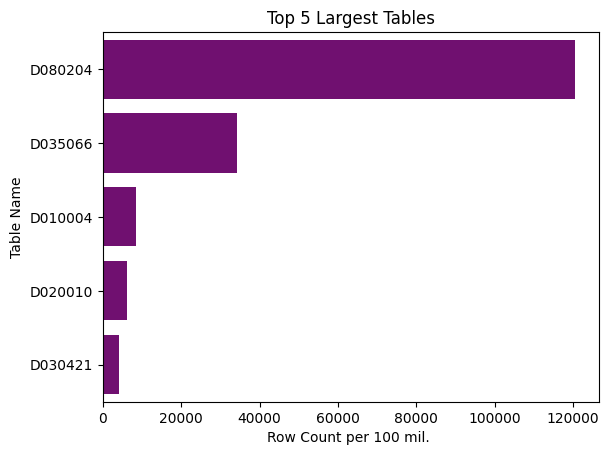

In [104]:
# Plot top largest tables

plt.figure()

sns.barplot(
    x='row_count',
    y='table_name',
    data=largest_tables,
    color='purple'
)

plt.title("Top 5 Largest Tables")
plt.xlabel("Row Count per 100 mil. ")
plt.ylabel("Table Name")

plt.show()

# Data Completeness Analysis

This section evaluates metadata completeness across the schema tables to identify missing descriptions, structural information, and relationship metadata.

In [105]:
# Check missing values

df.isnull().sum()

summary    10
tables      8
dtype: int64

In [106]:
# Count tables with sample data
table_df['has_sample_data'].value_counts()

has_sample_data
True    10
Name: count, dtype: int64

Result : The total number of tables present are 10 and the table under true are also 10, therefore we can conclude that each table contains some sample data. 

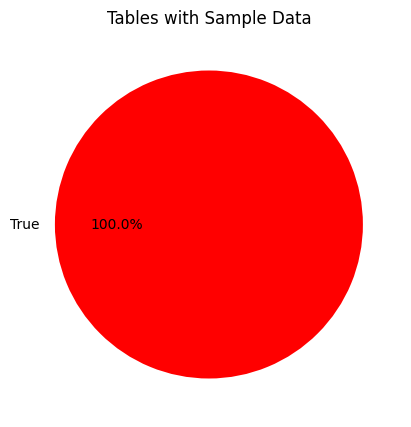

In [107]:
# Sample data availability
sample_counts = table_df['has_sample_data'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    sample_counts,
    labels=sample_counts.index,
    autopct='%1.1f%%',
    colors = "red"
)

plt.title("Tables with Sample Data")

plt.show()

# Primary and Foreign Key Analysis

Primary keys and foreign keys form the backbone of relational database architecture. This section analyzes schema connectivity, key availability, and relationship coverage across enterprise tables.

In databases:
Primary Key (PK) → unique identifier and 
Foreign Key (FK) → references another table

In [108]:
# Extract PK and FK information

key_info = []

for table_name, table in tables.items():
    
    pk_count = len(table.get('primary_keys', []))
    fk_count = len(table.get('foreign_keys', []))
    
    key_info.append({
        'table_name': table_name,
        'primary_key_count': pk_count,
        'foreign_key_count': fk_count
    })

# Convert to DataFrame
key_df = pd.DataFrame(key_info)

# Display
key_df.head(100)

,table_name,primary_key_count,foreign_key_count
0,D001001,1,0
1,D002007,1,0
2,D035066,1,1
3,D010004,1,0
4,D020010,1,0
5,D009081,1,0
6,ATMMASTER,1,1
7,D080204,1,0
8,D030421,1,0
9,D071031,1,0


In [109]:
#Tables with Primary and Foreign keys.

# Tables with PK
tables_with_pk = (key_df['primary_key_count'] > 0).sum()

# Tables with FK
tables_with_fk = (key_df['foreign_key_count'] > 0).sum()
print("Tables with PK:", tables_with_pk)
print("Tables with FK:", tables_with_fk)

both_pk_fk = (
    (key_df['primary_key_count'] > 0) &
    (key_df['foreign_key_count'] > 0)
).sum()
print ("Tables with both PK and FK :", both_pk_fk) 

only_pk = (
    (key_df['primary_key_count'] > 0) &
    (key_df['foreign_key_count'] == 0)
).sum()
print ("Tables with only PK  :", only_pk) 

only_fk = (
    (key_df['primary_key_count'] == 0) &
    (key_df['foreign_key_count'] > 0)
).sum()
print ("Tables with only FK  :", only_fk) 

neither = (
    (key_df['primary_key_count'] == 0) &
    (key_df['foreign_key_count'] == 0)
).sum()
print ("Tables with neither  :", neither) 

# Verify total

total = both_pk_fk + only_pk + only_fk + neither

print("Total Tables:", total)

Tables with PK: 10
Tables with FK: 2
Tables with both PK and FK : 2
Tables with only PK  : 8
Tables with only FK  : 0
Tables with neither  : 0
Total Tables: 10


Tables where foreign keys are present also has primary keys in there because the count of tables with both primary and foreign is 2 therefore there are no tables with just only foreign keys in it. 



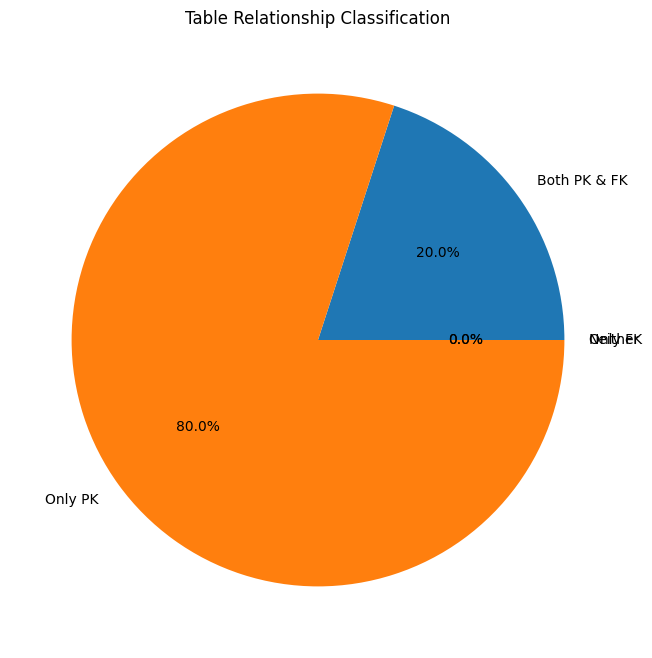

In [110]:
#visualization
# Labels and values

labels = [
    'Both PK & FK',
    'Only PK',
    'Only FK',
    'Neither'
]

values = [
    both_pk_fk,
    only_pk,
    only_fk,
    neither
]

# Plot

plt.figure(figsize=(8,8))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Table Relationship Classification")

plt.show()

## Key Observations

- Tables containing primary keys indicate structured entity-level design.
- Foreign key relationships demonstrate schema interconnectivity and relational maturity.
- Highly connected tables may represent core transactional or master business entities.
- Tables lacking primary keys may indicate staging, temporary, logging, or poorly documented structures.

# Column Metadata Extraction

This section extracts and profiles column-level metadata across all tables in the enterprise schema. The analysis focuses on data types, naming patterns, semantic categories, and metadata quality.

In [111]:
column_info = []

for table_name, table in tables.items():
    columns = table.get('columns', [])
    
    # Extract classification sets from the table metadata
    id_cols = set(table.get('id_columns', []))
    date_cols = set(table.get('date_columns', []))
    amount_cols = set(table.get('amount_columns', []))
    flag_cols = set(table.get('status_columns', [])) or set(table.get('flag_columns', []))

    for col in columns:
        # Map schema classifications to standard Oracle SQL data types
        if col in date_cols or 'DATE' in col.upper() or 'TIME' in col.upper():
            dtype = 'DATE'
        elif col in amount_cols or col in id_cols or 'AMT' in col.upper() or 'CODE' in col.upper():
            dtype = 'NUMBER'
        elif col in flag_cols or len(col) == 1 or 'FLAG' in col.upper():
            dtype = 'CHAR'
        else:
            dtype = 'VARCHAR2'

        column_info.append({
            'table_name': table_name,
            'column_name': col,
            'datatype': dtype
        })

# Create dataframe
column_df = pd.DataFrame(column_info)

print("Total Columns:", len(column_df))
column_df.head(10)

Total Columns: 55


,table_name,column_name,datatype
0,D001001,LBRCODE,NUMBER
1,D001001,BRANCH_NAME,VARCHAR2
2,D001001,CITY,VARCHAR2
3,D001001,STATE,VARCHAR2
4,D001001,IS_ACTIVE,CHAR
5,D002007,PBRCODE,NUMBER
6,D002007,USERCODE,NUMBER
7,D002007,LOGINDATE,DATE
8,D002007,LOGINTIME,DATE
9,D002007,CURRACTIVITY,VARCHAR2


In [112]:
column_df.describe(include='all')

,table_name,column_name,datatype
count,55,55,55
unique,10,46,4
top,D002007,LBRCODE,NUMBER
freq,8,4,26


# Datatype Distribution Analysis

Understanding datatype distribution helps identify schema design patterns and storage characteristics across the database.

In [113]:
datatype_counts = column_df['datatype'].value_counts()

datatype_counts

datatype
NUMBER      26
VARCHAR2    13
DATE        10
CHAR         6
Name: count, dtype: int64

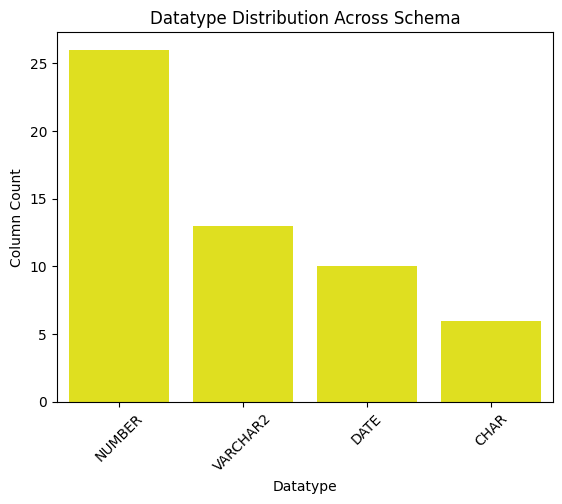

In [114]:
plt.figure()

sns.barplot(
    x=datatype_counts.index,
    y=datatype_counts.values,
    color = "yellow"
)

plt.xticks(rotation=45)

plt.title("Datatype Distribution Across Schema")
plt.xlabel("Datatype")
plt.ylabel("Column Count")

plt.show()

## Key Observations

- Datatype distribution provides insight into schema design patterns.
- Frequently occurring column names indicate common business entities and attributes.
- Wide tables may represent master records or highly denormalized structures.
- Noise column analysis helps evaluate metadata quality because is_noise is likely a flag generated by the metadata extraction process to indicate that a column is probably not useful for business analysis or relationship discovery.

# Domain Discovery and Business Classification

In [115]:
#loading the new file (contains clear domains for each tables)
domain_df = pd.read_csv("meta_phi_better_data.csv", index_col=False)
domain_df

,table_name,generated_metadata,business_domain,table_purpose,retrieval_description,keywords,example_questions,business_domain_better
0,D001001,"{'primary_entity': 'Branch Master', 'domain': ...",Banking & Financial Services,Branch operational master details and status l...,Branch parameters and location search.,"{Branch, LBRCODE, Operational, Location}",{What is the active status of a specific bank ...,Banking & Financial Services
1,D002007,"{'primary_entity': 'User Session', 'domain': '...",User Authentication System,User session login activities and access audit.,Password update and activity tracking.,"{Login, Audit, USERCODE, Timestamp}",{Show login activity for a specific user based...,User Authentication System
2,D035066,"{'primary_entity': 'ATM Txn', 'domain': 'Trans...",Banking and Financial Services,ATM transaction processing and ledger updates.,ATM reconciliation and financial reporting.,"{ATM, GST, Reconciliation, Audit}",{Find transaction details for a specific bank ...,Banking & Financial Services
3,D010004,"{'primary_entity': 'Account Master', 'domain':...",Core Banking Operations,Customer account profiles and live balances.,Account summary and balance lookups.,"{Account, Balance, CUST_ID, Deposit}",{What is the current balance and account type ...,Banking & Financial Services
4,D020010,"{'primary_entity': 'Customer Profile', 'domain...",Customer Relationship Management,Customer demographic information and national ...,PII search and customer identification.,"{Customer, PII, Demographics, Identity}",{Fetch demographic details and ID records for ...,Customer Relationship Management
5,D009081,"{'primary_entity': 'System Config', 'domain': ...",System Administration & Security,Application runtime parameters and timeout rules.,System configuration settings lookup.,"{Config, Timeout, Security, System}",{What is the current system session timeout se...,System Administration & Security
6,ATMMASTER,"{'primary_entity': 'ATM Registry', 'domain': '...",Terminal & Hardware Management,Physical ATM terminal locations and network st...,Terminal device status and hardware tracking.,"{ATM, Terminal, Hardware, Location}",{Which ATM terminals are currently online in B...,Terminal & Hardware Management
7,D080204,"{'primary_entity': 'Ledger Snapshot', 'domain'...",Accounting & Financial Reporting,Daily closing balances and accrued interest hi...,Ledger snapshot and balance history.,"{Ledger, Snapshot, Interest, Closing}",{Show the daily closing balance for account 10...,Accounting & Financial Reporting
8,D030421,"{'primary_entity': 'Cheque Record', 'domain': ...",Payment & Clearing Operations,Issued cheque leaf tracking and clearance flags.,Cheque clearance status verification.,"{Cheque, Clearance, Status, Amount}",{What is the clearance status of cheque number...,Payment & Clearing Operations
9,D071031,"{'primary_entity': 'Loan Schedule', 'domain': ...",Financial Services - Loan Management,Loan repayment schedules and installment track...,Overdue loan installment tracking.,"{Loan, Installment, Due Date, Repayment}",{List all overdue loan installments for a spec...,Banking & Financial Services


In [116]:
#count of number of tables under each domain.
domain_df['business_domain_better'].value_counts()

business_domain_better
Banking & Financial Services        4
User Authentication System          1
Customer Relationship Management    1
System Administration & Security    1
Terminal & Hardware Management      1
Accounting & Financial Reporting    1
Payment & Clearing Operations       1
Name: count, dtype: int64

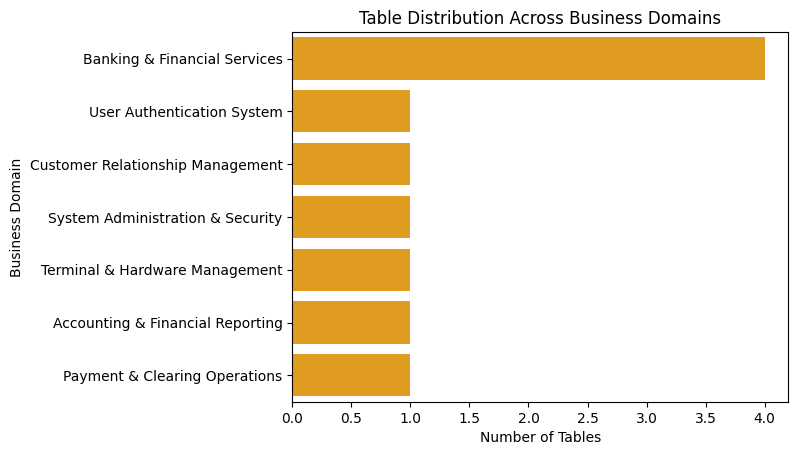

In [117]:
#visualization
domain_counts = domain_df['business_domain_better'].value_counts()

plt.figure()

sns.barplot(
    x=domain_counts.values,
    y=domain_counts.index,
    color = "orange"
)

plt.title("Table Distribution Across Business Domains")
plt.xlabel("Number of Tables")
plt.ylabel("Business Domain")

plt.show()

### Observation

The schema appears to be concentrated around a small number of business domains, indicating the primary operational focus areas of the organization.

In [118]:
#domains and their tables
domain_catalog = (
    domain_df
    .groupby('business_domain_better')['table_name']
    .apply(list)
    .reset_index()
)

domain_catalog.head(10)

,business_domain_better,table_name
0,Accounting & Financial Reporting,[D080204]
1,Banking & Financial Services,"[D001001, D035066, D010004, D071031]"
2,Customer Relationship Management,[D020010]
3,Payment & Clearing Operations,[D030421]
4,System Administration & Security,[D009081]
5,Terminal & Hardware Management,[ATMMASTER]
6,User Authentication System,[D002007]


In [119]:
#percentage of domains present.
domain_pct = (
    domain_df['business_domain_better']
    .value_counts(normalize=True)
    * 100
).round(2)

domain_pct

business_domain_better
Banking & Financial Services        40.0
User Authentication System          10.0
Customer Relationship Management    10.0
System Administration & Security    10.0
Terminal & Hardware Management      10.0
Accounting & Financial Reporting    10.0
Payment & Clearing Operations       10.0
Name: proportion, dtype: float64

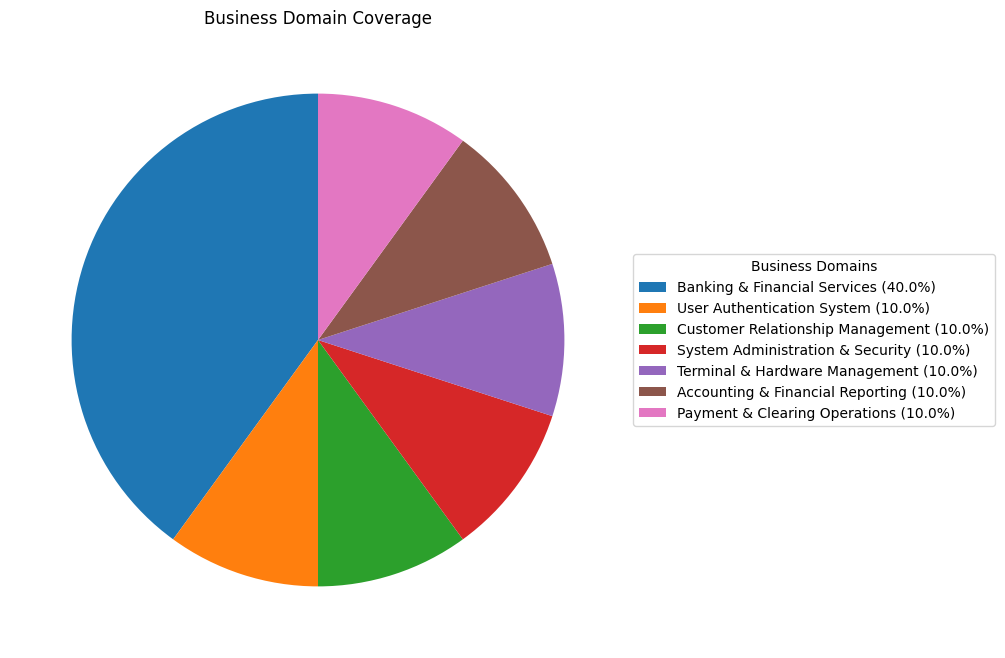

In [120]:
#visualization
plt.figure(figsize=(10,8))

# Create labels with percentages
legend_labels = [
    f"{domain} ({pct:.1f}%)"
    for domain, pct in zip(domain_pct.index, domain_pct.values)
]

wedges, _ = plt.pie(
    domain_pct.values,
    startangle=90
)

plt.legend(
    wedges,
    legend_labels,
    title="Business Domains",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Business Domain Coverage")

plt.show()

## Table Similarity

In [121]:
def check_backup(table_name):
    temp = info_1[info_1['table_name'] == table_name]
    result = temp['backup'].iloc[0]
    if result == 'yes':
        return True
    else:
        return False

In [122]:
# extracting specific columns
table_name_list = []
description_list = []
columns_list = []
columns_list_2 = []
foreign_keys_list = []
column_count_list = []
row_count_list = []

for table_name in sample_better_full_schema['tables'].keys():
    if check_backup(table_name):
        pass
    else:
        info = sample_better_full_schema['tables'][table_name]
        
        description = info.get('description', '')
        columns = info.get('columns', [])  # List of string column names
        
        # 1. Plain column names string
        better_columns = ', '.join(columns)
        
        # 2. Extract types from column_data_types dictionary if available
        data_types = info.get('column_data_types', {})
        better_columns_2 = [f"{col} ({data_types.get(col, 'VARCHAR2')})" for col in columns]
        better_columns_2 = ', '.join(better_columns_2)
        
        # 3. Handle foreign keys safely
        foreign_keys = info.get('foreign_keys', [])
        fk = [item['column_name'] if isinstance(item, dict) else str(item) for item in foreign_keys]
        fk = ', '.join(fk)

        column_count = info.get('column_count', len(columns))
        row_count = info.get('row_count', 0)
        
        column_count_list.append(column_count)
        row_count_list.append(row_count)
        
        table_name_list.append(table_name)
        description_list.append(description)
        columns_list.append(better_columns)
        columns_list_2.append(better_columns_2)
        foreign_keys_list.append(fk)

# Create DataFrame
df = pd.DataFrame()
df['table_name'] = table_name_list
df['description'] = description_list
df['columns'] = columns_list
df['columns_2'] = columns_list_2
df['column_count'] = column_count_list
df['row_count'] = row_count_list
df['foreign_keys'] = foreign_keys_list

df["column_set"] = (
    df["columns"]
    .fillna("")
    .str.lower()
    .apply(
        lambda x: {
            c.strip()
            for c in x.split(",")
            if c.strip()
        }
    )
)

In [123]:
df.head()

,table_name,description,columns,columns_2,column_count,row_count,foreign_keys,column_set
0,D001001,Stores branch parameters and operational maste...,"LBRCODE, BRANCH_NAME, CITY, STATE, IS_ACTIVE","LBRCODE (VARCHAR2), BRANCH_NAME (VARCHAR2), CI...",5,1250,,"{city, state, is_active, branch_name, lbrcode}"
1,D002007,Stores user login activities with timestamps a...,"PBRCODE, USERCODE, LOGINDATE, LOGINTIME, CURRA...","PBRCODE (VARCHAR2), USERCODE (VARCHAR2), LOGIN...",8,3502,,"{curractivity, usercode, srno, pbrcode, lbrcod..."
2,D035066,Stores transaction records with authorization ...,"TMAUTHNO, ENTRYDATE, TRANSAMT, CRLBRCODE, ATM_...","TMAUTHNO (VARCHAR2), ENTRYDATE (VARCHAR2), TRA...",7,34199,FK_D035066_LBR,"{transamt, atm_id, entrydate, drcr, tmauthno, ..."
3,D010004,Stores account master profiles and customer ow...,"ACCOUNT_NO, CUST_ID, OPEN_DATE, BALANCE, ACC_T...","ACCOUNT_NO (VARCHAR2), CUST_ID (VARCHAR2), OPE...",6,8500,,"{acc_type, balance, account_no, open_date, cus..."
4,D020010,Customer demographic and personal profile ledger.,"CUST_ID, FIRST_NAME, LAST_NAME, DOB, NATIONAL_ID","CUST_ID (VARCHAR2), FIRST_NAME (VARCHAR2), LAS...",5,6200,,"{last_name, national_id, first_name, cust_id, ..."


In [124]:
metadata_phi['business_domain_better'].value_counts().index.to_list()


['Banking & Financial Services',
 'User Authentication System',
 'Customer Relationship Management',
 'System Administration & Security',
 'Terminal & Hardware Management',
 'Accounting & Financial Reporting',
 'Payment & Clearing Operations']

In [125]:
# 1. Re-initialize dictionaries
schema_Banking__Financial_Services = {}
schema_User_Authentication_System = {}
schema_Customer_Relationship_Management = {}
schema_System_Administration__Security = {}
schema_Terminal__Hardware_Management = {}
schema_Accounting__Financial_Reporting = {}
schema_Payment__Clearing_Operations = {}

schema_all = {}

# 2. Merge df and metadata_phi on table_name
merged_df = pd.merge(df, metadata_phi, on='table_name', how='left')

# 3. Process the merged DataFrame directly
for _, row in merged_df.iterrows():
    table_name = str(row['table_name'])
    
    # Use retrieval_description if available, else fall back to description
    description = row['retrieval_description'] if pd.notna(row['retrieval_description']) else row['description']
    domain = str(row['business_domain_better']).strip() if pd.notna(row['business_domain_better']) else 'Unassigned'
    
    columns = row['columns_2']
    row_count = row['row_count']

    schema = f"""Table Name : {table_name}
Domain : {domain}
Description : {description}
Columns : {columns}
Row count : {row_count}"""

    schema_all[table_name] = schema

    # Route based on domain name
    if domain == 'Banking & Financial Services':
        schema_Banking__Financial_Services[table_name] = schema
    elif domain == 'User Authentication System':
        schema_User_Authentication_System[table_name] = schema
    elif domain == 'Customer Relationship Management':
        schema_Customer_Relationship_Management[table_name] = schema
    elif domain == 'System Administration & Security':
        schema_System_Administration__Security[table_name] = schema
    elif domain == 'Terminal & Hardware Management':
        schema_Terminal__Hardware_Management[table_name] = schema
    elif domain == 'Accounting & Financial Reporting':
        schema_Accounting__Financial_Reporting[table_name] = schema
    elif domain == 'Payment & Clearing Operations':
        schema_Payment__Clearing_Operations[table_name] = schema

# 4. Verify counts
print("Banking & Financial Services:", len(schema_Banking__Financial_Services))
print("User Authentication System:", len(schema_User_Authentication_System))
print("Customer Relationship Management:", len(schema_Customer_Relationship_Management))
print("System Administration & Security:", len(schema_System_Administration__Security))
print("Terminal & Hardware Management:", len(schema_Terminal__Hardware_Management))
print("Accounting & Financial Reporting:", len(schema_Accounting__Financial_Reporting))
print("Payment & Clearing Operations:", len(schema_Payment__Clearing_Operations))

Banking & Financial Services: 4
User Authentication System: 1
Customer Relationship Management: 1
System Administration & Security: 1
Terminal & Hardware Management: 1
Accounting & Financial Reporting: 1
Payment & Clearing Operations: 1


In [126]:
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np

# Load model
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    trust_remote_code=True
)

table_embeddings = model.encode(
    list(schema_all.values()),
    normalize_embeddings=True,
    show_progress_bar=True
)

print(table_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(10, 384)


In [127]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# "sentence-transformers/all-MiniLM-L6-v2"
# "BAAI/bge-large-en-v1.5"


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [128]:
schema_all

{'D001001': 'Table Name : D001001\nDomain : Banking & Financial Services\nDescription : Branch parameters and location search.\nColumns : LBRCODE (VARCHAR2), BRANCH_NAME (VARCHAR2), CITY (VARCHAR2), STATE (VARCHAR2), IS_ACTIVE (VARCHAR2)\nRow count : 1250',
 'D002007': 'Table Name : D002007\nDomain : User Authentication System\nDescription : Password update and activity tracking.\nColumns : PBRCODE (VARCHAR2), USERCODE (VARCHAR2), LOGINDATE (VARCHAR2), LOGINTIME (VARCHAR2), CURRACTIVITY (VARCHAR2), ACTDATE (VARCHAR2), SRNO (VARCHAR2), LBRCODE (VARCHAR2)\nRow count : 3502',
 'D035066': 'Table Name : D035066\nDomain : Banking & Financial Services\nDescription : ATM reconciliation and financial reporting.\nColumns : TMAUTHNO (VARCHAR2), ENTRYDATE (VARCHAR2), TRANSAMT (VARCHAR2), CRLBRCODE (VARCHAR2), ATM_ID (VARCHAR2), DRCR (VARCHAR2), STATUS (VARCHAR2)\nRow count : 34199',
 'D010004': 'Table Name : D010004\nDomain : Banking & Financial Services\nDescription : Account summary and balance 

In [129]:
# 3. Generate embeddings for all active schemas
embeddings = model.encode(
    list(schema_all.values()),
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings_schema_Banking__Financial_Services = model.encode(
    list(schema_Banking__Financial_Services.values()),
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings_schema_User_Authentication_System = model.encode(
    list(schema_User_Authentication_System.values()),
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings_schema_Customer_Relationship_Management = model.encode(
    list(schema_Customer_Relationship_Management.values()),
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings_schema_System_Administration__Security = model.encode(
    list(schema_System_Administration__Security.values()),
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings_schema_Terminal__Hardware_Management = model.encode(
    list(schema_Terminal__Hardware_Management.values()),
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings_schema_Accounting__Financial_Reporting = model.encode(
    list(schema_Accounting__Financial_Reporting.values()),
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings_schema_Payment__Clearing_Operations = model.encode(
    list(schema_Payment__Clearing_Operations.values()),
    normalize_embeddings=True,
    show_progress_bar=True
)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [130]:
embeddings.shape

(10, 384)

In [147]:
embeddings_schema_Accounting__Financial_Reporting.shape

(1, 384)

In [148]:
emb_1 = embeddings_schema_Accounting__Financial_Reporting
emb_2 = embeddings_schema_Customer_Relationship_Management

emb_1.shape

(1, 384)

In [150]:
import numpy as np

def check_similarity(emb_1, emb_2):
    # Guard clause: check if either embedding array is empty or has 0 rows
    if emb_1.size == 0 or emb_2.size == 0 or emb_1.shape[0] == 0 :
        return None, None, None

    list_temp = []
    
    # Check if comparing the exact same array/object
    if str(emb_1) == str(emb_2):
        for i in range(emb_1.shape[0]):
            for j in range(emb_2.shape[0]):
                if i != j:
                    temp = np.dot(emb_1[i, :], emb_2[j, :])
                    list_temp.append(temp)
    else:
        for i in range(emb_1.shape[0]):
            for j in range(emb_2.shape[0]):
                temp = np.dot(emb_1[i, :], emb_2[j, :])
                list_temp.append(temp)

    # Secondary check in case no comparisons were added
    if not list_temp:
        return None, None, None

    return np.min(list_temp), np.max(list_temp), np.mean(list_temp)

In [152]:
for item in list_emb:
    print(check_similarity(item,embeddings_schema_Payment__Clearing_Operations))

(np.float32(0.6099149), np.float32(0.74236333), np.float32(0.6917436))
(np.float32(0.60385716), np.float32(0.60385716), np.float32(0.60385716))
(np.float32(0.53191483), np.float32(0.53191483), np.float32(0.53191483))
(np.float32(0.5518272), np.float32(0.5518272), np.float32(0.5518272))
(np.float32(0.5594183), np.float32(0.5594183), np.float32(0.5594183))
(np.float32(0.69129574), np.float32(0.69129574), np.float32(0.69129574))
(None, None, None)


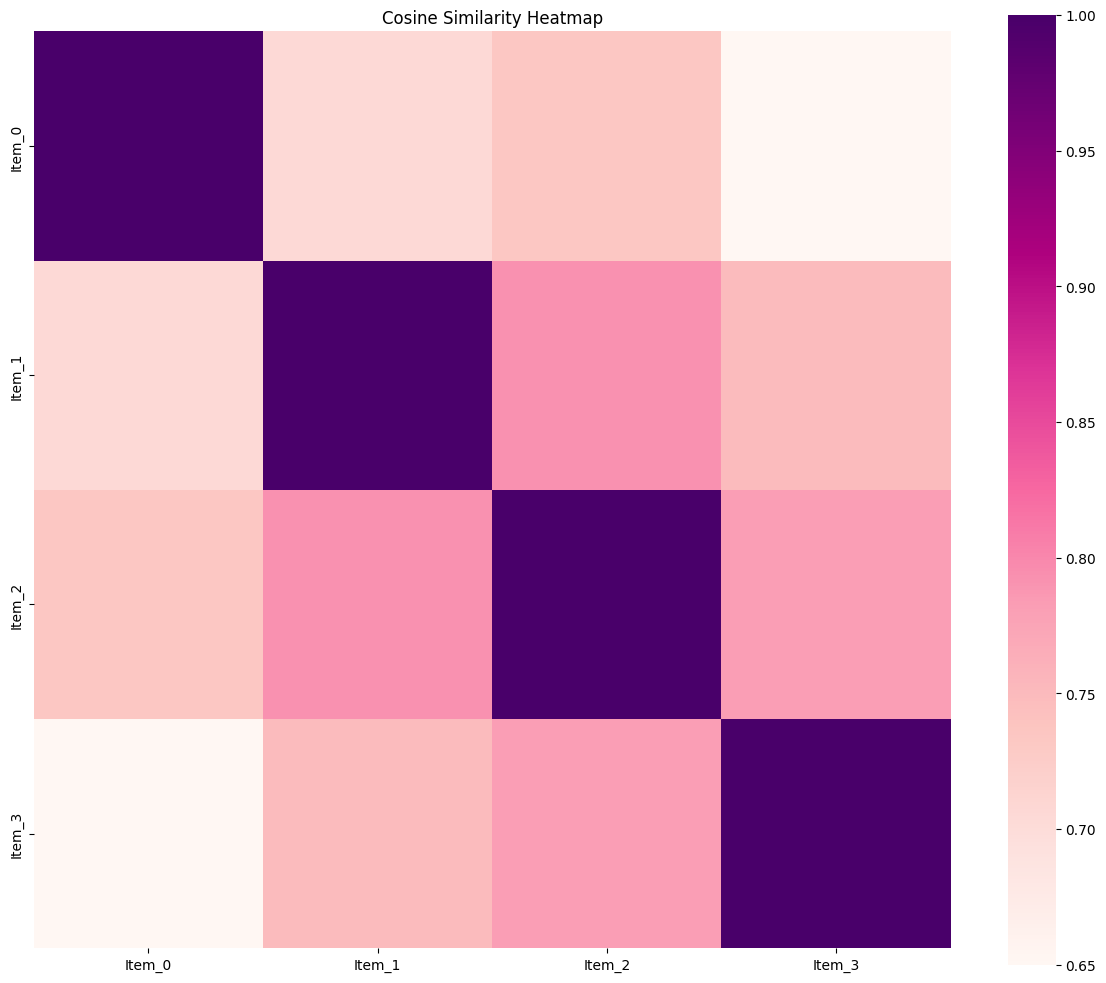

In [156]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# embeddings: numpy array of shape (n_samples, embedding_dim)
# labels: optional names for rows/columns

similarity_matrix = cosine_similarity(embeddings_schema_Banking__Financial_Services)

# Optional labels
labels = [f"Item_{i}" for i in range(len(embeddings_schema_Banking__Financial_Services))]

sim_df = pd.DataFrame(
    similarity_matrix,
    index=labels,
    columns=labels
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    sim_df,
    cmap="RdPu",
    annot=False,
    square=True,
)

plt.title("Cosine Similarity Heatmap")
plt.tight_layout()
plt.show()

In [158]:
#validating the semantic relationships between different business domains using their embedding vectors.
check_similarity(embeddings_schema_User_Authentication_System,embeddings_schema_Payment__Clearing_Operations)
#returns similarity scores.

(np.float32(0.60385716), np.float32(0.60385716), np.float32(0.60385716))

### A higher similarity score (closer to 1) indicates that the domains share similar business concepts, terminology, or data characteristics, while a lower score indicates that they are more distinct.

### From this we can infer that the domains are not clearly seperated!

# Conclusion

This exploratory analysis provided a focused overview of the target database schema by examining its structure, metadata, key relationships, business domains, and semantic similarities across **10** core tables.

The analysis identified the structural characteristics of the schema through table profiling, data completeness assessment, primary and foreign key analysis, column metadata exploration, data type distribution, and business domain classification. The presence of primary and foreign key relationships highlights a connected relational structure, enabling clear navigation across the primary data entities.

Business domain classification offered a high-level view of the functional areas represented in the schema, while semantic similarity analysis using embeddings revealed that several domains exhibit strong semantic overlap. The cosine similarity evaluations and pairwise checks indicate that the business domains are not strictly isolated, as they share common entities, processes, and terminology. This suggests an interconnected data model where functional areas interact closely rather than existing as completely independent silos.

Overall, the schema demonstrates a rich structure supported by descriptive metadata, relational links, and semantic context. This report serves as a foundational reference for analysts, developers, and data engineers by providing a clear understanding of the table organization, highlighting key entities and relationships, and establishing a baseline for future data discovery, schema exploration, and pipeline integration.